In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import sys
import os

# Add the models directory to the Python path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from models.linear_regression import LinearRegression

## 1. Generate Synthetic Data

We'll use `make_regression` from scikit-learn to create a simple dataset with one feature for easy visualization.

In [2]:
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Reshape y to be a row vector (1, m) as expected by the model's cost function
y = y.reshape(1, -1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y.T, test_size=0.2, random_state=123) # y needs to be (m, 1) for train_test_split

# Transpose X to match the model's expected input shape (input_dim, m)
X_train = X_train.T
X_test = X_test.T
y_train = y_train.T # Back to (1, m_train)
y_test = y_test.T   # Back to (1, m_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1, 80)
y_train shape: (1, 80)
X_test shape: (1, 20)
y_test shape: (1, 20)


## 2. Train the Linear Regression Model

In [3]:
# Instantiate the model
# input_dim is the number of features (rows in X_train)
input_dim = X_train.shape[0]
lr_model = LinearRegression(input_dim=input_dim, learning_rate=0.01, n_iterations=500)

# Fit the model
costs = lr_model.fit(X_train, y_train)

# Print learned parameters
print(f"Learned W: {lr_model.W}")
print(f"Learned b: {lr_model.b}")

Learned W: [[43.23243033]]
Learned b: [[0.1966435]]


## 3. Evaluate the Model

In [4]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Calculate Mean Squared Error
# Note: sklearn's mse expects (n_samples,) or (n_samples, n_outputs)
mse = mean_squared_error(y_test.flatten(), y_pred.flatten())
print(f"Mean Squared Error on Test Set: {mse:.4f}")

Mean Squared Error on Test Set: 71.4392


## 4. Visualize the Results

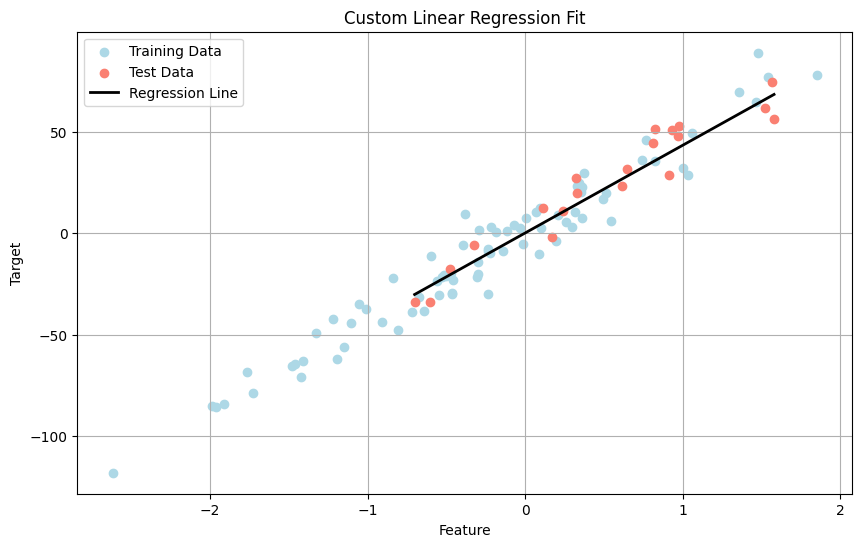

In [5]:
# Plot the training data, test data, and the regression line
plt.figure(figsize=(10, 6))

# Scatter plot for training data
plt.scatter(X_train.T[:, 0], y_train.T[:, 0], color='lightblue', label='Training Data')

# Scatter plot for test data
plt.scatter(X_test.T[:, 0], y_test.T[:, 0], color='salmon', label='Test Data')

# Plot the regression line using test predictions
# Sort values for a continuous line plot
sort_indices = np.argsort(X_test[0, :])
plt.plot(X_test[0, sort_indices], y_pred[0, sort_indices], color='black', linewidth=2, label='Regression Line')

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Custom Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

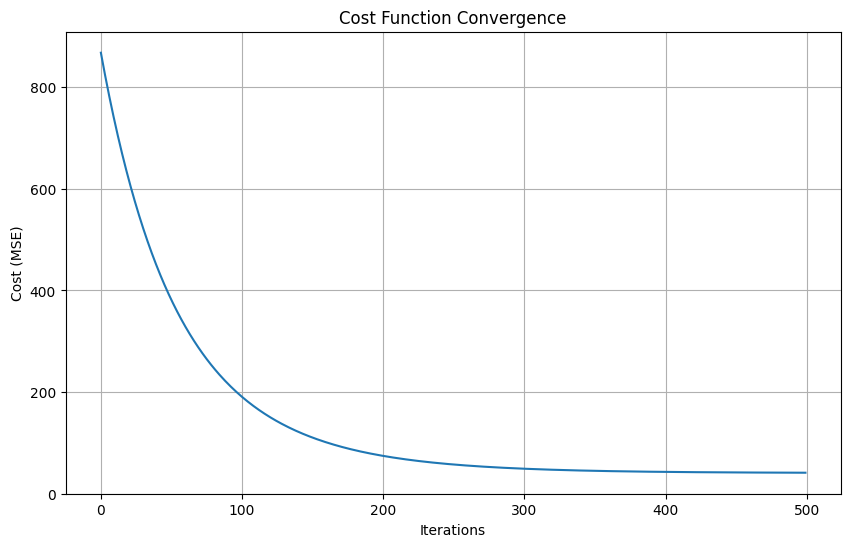

In [6]:
# Plot the cost over iterations
plt.figure(figsize=(10, 6))
plt.plot(range(lr_model.n_iterations), costs)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost Function Convergence")
plt.grid(True)
plt.show()